## Preprocessing Precinct Boundaries

In [1]:
import pandas as pd
import pygris
import geopandas
import topojson as tp
import maup
import json

### Arkansas Precinct Boundary Path

#### CVAP Census Data Estimates

In [2]:
path = '../../data/Arkansas/ar-cb-CVAP.csv'

In [3]:
cb_df = pd.read_csv(path)
cb_df

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,1,486,149,409,103
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,2,444,131,391,106
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,3,0,13,0,13
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,4,0,13,0,13
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,5,7,6,0,13
...,...,...,...,...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,9,0,15,0,15
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,10,0,15,0,15
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,11,0,15,0,15
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,12,0,15,0,15


In [4]:
cb_df = cb_df[['geoname', 'lntitle', 'geoid', 'cvap_est']]
cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,391
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,0
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,0
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,0
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,0
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,0
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,0


In [5]:
relevant_groups = ['Total', 'Black or African American Alone', 'White Alone', 'Hispanic or Latino']
cb_df = cb_df[cb_df['lntitle'].isin(relevant_groups)]
cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
6,"Block Group 1, Census Tract 201, Autauga Count...",White Alone,1500000US010010201001,358
12,"Block Group 1, Census Tract 201, Autauga Count...",Hispanic or Latino,1500000US010010201001,18
13,"Block Group 2, Census Tract 201, Autauga Count...",Total,1500000US010010201002,909
...,...,...,...,...
3149847,"Block Group 1, Census Tract 7506.02, Yauco Mun...",Hispanic or Latino,1500000US721537506021,1081
3149848,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Total,1500000US721537506022,771
3149852,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American Alone,1500000US721537506022,0
3149854,"Block Group 2, Census Tract 7506.02, Yauco Mun...",White Alone,1500000US721537506022,0


In [6]:
grouped = (
    cb_df[cb_df['lntitle'] != 'Total']
    .groupby(['geoid', 'geoname'])['cvap_est']
    .sum()
    .reset_index()
)

totals = cb_df[cb_df['lntitle'] == 'Total'][['geoid', 'geoname', 'cvap_est']]

merged = totals.merge(
    grouped,
    on=['geoid', 'geoname'],
    suffixes=('_Total', '_Known')
)

merged['Other'] = merged['cvap_est_Total'] - merged['cvap_est_Known']

other_rows = merged[['geoid', 'geoname', 'Other']].rename(columns={'Other': 'cvap_est'})
other_rows['lntitle'] = 'Other'

cb_df = pd.concat(
    [cb_df, other_rows[['geoid', 'geoname', 'lntitle', 'cvap_est']]],
    ignore_index=True
)

cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
2,"Block Group 1, Census Tract 201, Autauga Count...",White Alone,1500000US010010201001,358
3,"Block Group 1, Census Tract 201, Autauga Count...",Hispanic or Latino,1500000US010010201001,18
4,"Block Group 2, Census Tract 201, Autauga Count...",Total,1500000US010010201002,909
...,...,...,...,...
1211480,"Block Group 1, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506011,0
1211481,"Block Group 2, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506012,0
1211482,"Block Group 3, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506013,0
1211483,"Block Group 1, Census Tract 7506.02, Yauco Mun...",Other,1500000US721537506021,0


In [7]:
cb_df = cb_df.sort_values(by='geoname')
cb_df

,geoname,lntitle,geoid,cvap_est
566151,"Block Group 0, Census Tract 1, Bronx County, N...",Hispanic or Latino,1500000US360050001000,0
566148,"Block Group 0, Census Tract 1, Bronx County, N...",Total,1500000US360050001000,0
566149,"Block Group 0, Census Tract 1, Bronx County, N...",Black or African American Alone,1500000US360050001000,0
566150,"Block Group 0, Census Tract 1, Bronx County, N...",White Alone,1500000US360050001000,0
1110725,"Block Group 0, Census Tract 1, Bronx County, N...",Other,1500000US360050001000,0
...,...,...,...,...
383191,"Block Group 9, Census Tract 9618.01, St. Landr...",Hispanic or Latino,1500000US220979618019,25
383188,"Block Group 9, Census Tract 9618.01, St. Landr...",Total,1500000US220979618019,169
1064985,"Block Group 9, Census Tract 9618.01, St. Landr...",Other,1500000US220979618019,0
383190,"Block Group 9, Census Tract 9618.01, St. Landr...",White Alone,1500000US220979618019,144


##### Only Arkansas

In [8]:
ar_cb = cb_df[cb_df['geoname'].str.endswith('Arkansas')]
ar_cb

,geoname,lntitle,geoid,cvap_est
44258,"Block Group 1, Census Tract 1, Sebastian Count...",White Alone,1500000US051310001001,128
44257,"Block Group 1, Census Tract 1, Sebastian Count...",Black or African American Alone,1500000US051310001001,233
44259,"Block Group 1, Census Tract 1, Sebastian Count...",Hispanic or Latino,1500000US051310001001,155
44256,"Block Group 1, Census Tract 1, Sebastian Count...",Total,1500000US051310001001,593
980252,"Block Group 1, Census Tract 1, Sebastian Count...",Other,1500000US051310001001,77
...,...,...,...,...
978791,"Block Group 7, Census Tract 3, Craighead Count...",Other,1500000US050310003007,7
38415,"Block Group 7, Census Tract 3, Craighead Count...",Hispanic or Latino,1500000US050310003007,0
38412,"Block Group 7, Census Tract 3, Craighead Count...",Total,1500000US050310003007,924
38413,"Block Group 7, Census Tract 3, Craighead Count...",Black or African American Alone,1500000US050310003007,0


In [9]:
ar_cb.drop(columns='geoname', inplace=True)
ar_cb

,lntitle,geoid,cvap_est
44258,White Alone,1500000US051310001001,128
44257,Black or African American Alone,1500000US051310001001,233
44259,Hispanic or Latino,1500000US051310001001,155
44256,Total,1500000US051310001001,593
980252,Other,1500000US051310001001,77
...,...,...,...
978791,Other,1500000US050310003007,7
38415,Hispanic or Latino,1500000US050310003007,0
38412,Total,1500000US050310003007,924
38413,Black or African American Alone,1500000US050310003007,0


In [10]:
ar_cb['COUNTYFP'] = ar_cb['geoid'].str.extract(r'1500000US05(\d{3})')
ar_cb

,lntitle,geoid,cvap_est,COUNTYFP
44258,White Alone,1500000US051310001001,128,131
44257,Black or African American Alone,1500000US051310001001,233,131
44259,Hispanic or Latino,1500000US051310001001,155,131
44256,Total,1500000US051310001001,593,131
980252,Other,1500000US051310001001,77,131
...,...,...,...,...
978791,Other,1500000US050310003007,7,031
38415,Hispanic or Latino,1500000US050310003007,0,031
38412,Total,1500000US050310003007,924,031
38413,Black or African American Alone,1500000US050310003007,0,031


In [11]:
ar_cb = ar_cb.sort_values(by=['COUNTYFP', 'geoid'])
ar_cb

,lntitle,geoid,cvap_est,COUNTYFP
36811,Hispanic or Latino,1500000US050014801001,0,001
36809,Black or African American Alone,1500000US050014801001,98,001
978390,Other,1500000US050014801001,20,001
36808,Total,1500000US050014801001,811,001
36810,White Alone,1500000US050014801001,693,001
...,...,...,...,...
45983,Hispanic or Latino,1500000US051499526003,19,149
45982,White Alone,1500000US051499526003,774,149
980683,Other,1500000US051499526003,0,149
45980,Total,1500000US051499526003,793,149


#### NYT Precinct Election Data

In [12]:
nyt_path = '../../data/Arkansas/nyt-ar-precinct.geojson'

In [13]:
nyt_gdf = geopandas.read_file(nyt_path)
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,-0.3638,True,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,-0.2121,True,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,-0.5744,True,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,0.2395,True,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,-0.7256,True,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,-0.2166,True,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,-0.6250,True,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,AR,05149-29 - Ions Creek,0,19,19,-1.0000,True,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,AR,05149-24 - Waveland,18,69,88,-0.5795,True,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [14]:
nyt_gdf['GEOID'].nunique()

2681

In [15]:
nyt_gdf = nyt_gdf[['state', 'GEOID', 'votes_dem', 'votes_rep', 'votes_total', 'geometry']]
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125..."
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((-93.70875 34.83304, -93.70875 34.833..."
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((-93.59987 35.14713, -93.60034 35.147..."


In [16]:
nyt_gdf['COUNTYFP'] = nyt_gdf['GEOID'].str.extract(r'^..(\d{3})')
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,geometry,COUNTYFP
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ...",001
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131...",001
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((-91.32906 34.28234, -91.32906 34.282...",001
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((-91.32906 34.28234, -91.329 34.28234...",001
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((-91.34062 34.30203, -91.34062 34.302...",001
...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126...",149
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((-93.27993 35.21256, -93.2806 35.2125...",149
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((-93.70875 34.83304, -93.70875 34.833...",149
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((-93.59987 35.14713, -93.60034 35.147...",149


#### Merge

In [17]:
nyt_df = nyt_gdf
cvap_df = ar_cb

In [18]:
cvap_df["bg_geoid"] = cvap_df["geoid"].str.replace("1500000US", "")
cvap_df

,lntitle,geoid,cvap_est,COUNTYFP,bg_geoid
36811,Hispanic or Latino,1500000US050014801001,0,001,050014801001
36809,Black or African American Alone,1500000US050014801001,98,001,050014801001
978390,Other,1500000US050014801001,20,001,050014801001
36808,Total,1500000US050014801001,811,001,050014801001
36810,White Alone,1500000US050014801001,693,001,050014801001
...,...,...,...,...,...
45983,Hispanic or Latino,1500000US051499526003,19,149,051499526003
45982,White Alone,1500000US051499526003,774,149,051499526003
980683,Other,1500000US051499526003,0,149,051499526003
45980,Total,1500000US051499526003,793,149,051499526003


In [19]:
cvap_df['geoid']

36811     1500000US050014801001
36809     1500000US050014801001
978390    1500000US050014801001
36808     1500000US050014801001
36810     1500000US050014801001
                  ...          
45983     1500000US051499526003
45982     1500000US051499526003
980683    1500000US051499526003
45980     1500000US051499526003
45981     1500000US051499526003
Name: geoid, Length: 11470, dtype: object

In [20]:
race_map = {
    "Total"                              : "cvap_total",
    "White Alone"                        : "cvap_white",
    "Black or African American Alone"    : "cvap_black",
    "Hispanic or Latino"                 : "cvap_hispanic",
    "Other"                              : "cvap_other",
}

cvap_filtered = cvap_df[cvap_df["lntitle"].isin(race_map)].copy()
cvap_filtered["lntitle"] = cvap_filtered["lntitle"].map(race_map)
cvap_filtered

,lntitle,geoid,cvap_est,COUNTYFP,bg_geoid
36811,cvap_hispanic,1500000US050014801001,0,001,050014801001
36809,cvap_black,1500000US050014801001,98,001,050014801001
978390,cvap_other,1500000US050014801001,20,001,050014801001
36808,cvap_total,1500000US050014801001,811,001,050014801001
36810,cvap_white,1500000US050014801001,693,001,050014801001
...,...,...,...,...,...
45983,cvap_hispanic,1500000US051499526003,19,149,051499526003
45982,cvap_white,1500000US051499526003,774,149,051499526003
980683,cvap_other,1500000US051499526003,0,149,051499526003
45980,cvap_total,1500000US051499526003,793,149,051499526003


In [21]:
cvap_wide = (
    cvap_filtered
    .pivot_table(index="bg_geoid", columns="lntitle", values="cvap_est", aggfunc="sum")
    .reset_index()
)
cvap_wide.columns.name = None
cvap_wide

,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050014801001,98,0,20,811,693
1,050014802001,46,61,7,1153,1039
2,050014803001,362,7,0,656,287
3,050014803002,180,0,10,1343,1153
4,050014804001,772,0,45,999,182
...,...,...,...,...,...,...
2289,051499525003,5,54,13,480,408
2290,051499525004,0,22,0,785,763
2291,051499526001,0,22,6,613,585
2292,051499526002,7,6,36,418,369


In [22]:
bg = pygris.block_groups(state='AR', year=2020)
bg = bg[["GEOID", "geometry"]].copy()        

bg = bg.merge(cvap_wide, left_on="GEOID", right_on="bg_geoid", how="left")
bg

Using FIPS code '05' for input 'AR'


,GEOID,geometry,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050310011011,"POLYGON ((-90.64716 35.91775, -90.64714 35.917...",050310011011,0,9,34,1811,1768
1,050310011022,"POLYGON ((-90.58719 35.9297, -90.58694 35.9301...",050310011022,0,0,30,574,544
2,050310011021,"POLYGON ((-90.56687 35.87831, -90.56416 35.878...",050310011021,0,0,0,523,523
3,050310004041,"POLYGON ((-90.68694 35.78915, -90.68646 35.789...",050310004041,517,202,85,2223,1419
4,050310004031,"POLYGON ((-90.7027 35.82138, -90.70236 35.8213...",050310004031,35,0,52,1096,1009
...,...,...,...,...,...,...,...,...
2289,050634901023,"POLYGON ((-91.66623 35.8463, -91.66618 35.8463...",050634901023,0,24,24,748,700
2290,050634901021,"POLYGON ((-91.59292 35.8246, -91.59276 35.8249...",050634901021,0,32,10,1046,1004
2291,050634903005,"POLYGON ((-91.64259 35.78524, -91.64253 35.785...",050634903005,0,32,55,589,502
2292,050070205031,"POLYGON ((-94.19751 36.33631, -94.19749 36.337...",050070205031,14,134,67,629,414


In [23]:
print(nyt_df.head())
print(bg.head())

  state                      GEOID  votes_dem  votes_rep  votes_total  \
0    AR     05001-81 - Stuttgart 2        293        639          951   
1    AR  05001-36 - Gillett Ward 3         25         39           66   
2    AR        05001-53 - Dewitt 2         49        188          242   
3    AR        05001-51 - DeWitt 1        101         61          167   
4    AR        05001-55 - Dewitt 3         42        272          317   

                                            geometry COUNTYFP  
0  MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ...      001  
1  POLYGON ((-91.38939 34.1162, -91.38947 34.1131...      001  
2  POLYGON ((-91.32906 34.28234, -91.32906 34.282...      001  
3  POLYGON ((-91.32906 34.28234, -91.329 34.28234...      001  
4  POLYGON ((-91.34062 34.30203, -91.34062 34.302...      001  
          GEOID                                           geometry  \
0  050310011011  POLYGON ((-90.64716 35.91775, -90.64714 35.917...   
1  050310011022  POLYGON ((-90.58719 

In [24]:
precincts = geopandas.GeoDataFrame(nyt_gdf, geometry="geometry")
blocks = geopandas.GeoDataFrame(bg, geometry="geometry")

In [25]:
# change to CRS for blocks / was orignally in GPS
precincts = precincts.to_crs(precincts.estimate_utm_crs())
blocks = blocks.to_crs(blocks.estimate_utm_crs())
print(precincts.crs)
print(blocks.crs)

EPSG:32615
EPSG:32615


<Axes: >

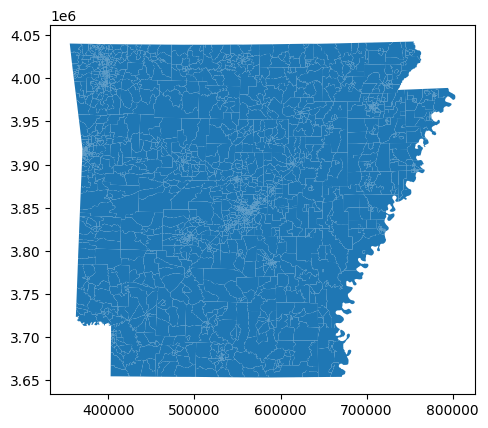

In [26]:
blocks.plot(None)

In [27]:
print(precincts.head())
print(blocks.head())

print(precincts.crs)
print(blocks.crs)


  state                      GEOID  votes_dem  votes_rep  votes_total  \
0    AR     05001-81 - Stuttgart 2        293        639          951   
1    AR  05001-36 - Gillett Ward 3         25         39           66   
2    AR        05001-53 - Dewitt 2         49        188          242   
3    AR        05001-51 - DeWitt 1        101         61          167   
4    AR        05001-55 - Dewitt 3         42        272          317   

                                            geometry COUNTYFP  
0  MULTIPOLYGON (((635621.038 3816237.2, 635621.7...      001  
1  POLYGON ((648540.76 3776211.027, 648538.959 37...      001  
2  POLYGON ((653803.262 3794725.095, 653803.256 3...      001  
3  POLYGON ((653803.262 3794725.095, 653808.455 3...      001  
4  POLYGON ((652703.83 3796891.285, 652703.43 379...      001  
          GEOID                                           geometry  \
0  050310011011  POLYGON ((712294.354 3977383.331, 712295.756 3...   
1  050310011022  POLYGON ((717673.965

In [28]:
precincts['geometry'] = precincts.buffer(0)
blocks['geometry'] = blocks.buffer(0)

In [29]:
demo_col = ['cvap_white', 'cvap_black','cvap_hispanic','cvap_other','cvap_total']

In [30]:
pieces = maup.intersections(blocks, precincts, area_cutoff=0)
print("Number of intersection pieces:", len(pieces))

weights = pieces.area / pieces.index.get_level_values(0).map(blocks.area)
aggregated_prorate = maup.prorate(pieces, blocks[demo_col], weights)
aggregated_prorate = aggregated_prorate.reindex(precincts.index, fill_value=0)

print("Zero population after prorate:", 
      (aggregated_prorate["cvap_total"] == 0).sum())

Number of intersection pieces: 13324
Zero population after prorate: 0


In [31]:
precincts["White_population"] = aggregated_prorate["cvap_white"].values
precincts["Black_population"] = aggregated_prorate["cvap_black"].values
precincts["Latino_population"] = aggregated_prorate["cvap_hispanic"].values
precincts["Other_population"] = aggregated_prorate["cvap_other"].values
precincts["Total_population"] = aggregated_prorate["cvap_total"].values

In [32]:
cvap_cols = [c for c in precincts.columns if c.endswith("_population")]

for col in [c for c in cvap_cols if c != "cvap_total"]:
    precincts[f"{col.replace('_population', '')}_percentage"] = (
        precincts[col] / precincts["Total_population"]
    )

In [33]:
precincts.head()

,state,GEOID,votes_dem,votes_rep,votes_total,geometry,COUNTYFP,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,Total_percentage
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((635621.038 3816237.2, 635596.6...",001,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,1.0
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((648540.76 3776211.027, 648565.197 37...",001,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,1.0
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((653803.262 3794725.095, 653468.214 3...",001,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,1.0
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((653803.262 3794725.095, 653803.256 3...",001,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,1.0
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((652703.83 3796891.285, 652703.836 37...",001,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,1.0


### Final Cleanup

In [34]:
precincts["name"] = precincts["GEOID"]
precincts['votes_other'] = precincts['votes_total'] - precincts['votes_rep'] - precincts['votes_dem']

In [35]:
ar_precincts = precincts.drop(columns=['state', 'GEOID', 'Total_percentage'])
ar_precincts.columns

Index(['votes_dem', 'votes_rep', 'votes_total', 'geometry', 'COUNTYFP',
       'White_population', 'Black_population', 'Latino_population',
       'Other_population', 'Total_population', 'White_percentage',
       'Black_percentage', 'Latino_percentage', 'Other_percentage', 'name',
       'votes_other'],
      dtype='object')

In [36]:
cols = [
    "name", "COUNTYFP",
    "votes_dem", "votes_rep", "votes_other", "votes_total",
    "White_population", "Black_population", "Latino_population", "Other_population", "Total_population",
    "White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage",
    "geometry"
]

ar_precincts = ar_precincts[cols]
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((635621.038 3816237.2, 635596.6..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((648540.76 3776211.027, 648565.197 37..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((653803.262 3794725.095, 653468.214 3..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((653803.262 3794725.095, 653803.256 3..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((652703.83 3796891.285, 652703.836 37..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((485442.696 3896709.11, 485442.697 38..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.771656,0.000000,69.264875,45.229594,878.266125,0.869636,0.000000,0.078865,0.051499,"POLYGON ((474521.938 3896651.166, 474560.29 38..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.619378,2.686534,2.302779,13.816510,160.425201,0.882775,0.016746,0.014354,0.086124,"POLYGON ((435193.704 3854757.434, 435195.69 38..."
2679,05149-24 - Waveland,149,18,69,1,88,253.901601,7.571889,4.456923,9.800575,275.730988,0.920831,0.027461,0.016164,0.035544,"POLYGON ((445358.906 3889523.661, 445358.903 3..."


In [37]:
ar_precincts = geopandas.GeoDataFrame(ar_precincts, geometry='geometry')
ar_precincts = ar_precincts.set_crs("EPSG:32615", allow_override=True)
ar_precincts = ar_precincts.to_crs("EPSG:4326") 
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((-91.52313 34.47881, -91.5234 3..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((-91.38939 34.1162, -91.38913 34.1162..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((-91.32906 34.28234, -91.3327 34.2822..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((-93.15995 35.2133, -93.15995 35.2133..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.771656,0.000000,69.264875,45.229594,878.266125,0.869636,0.000000,0.078865,0.051499,"POLYGON ((-93.27993 35.21256, -93.27951 35.212..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.619378,2.686534,2.302779,13.816510,160.425201,0.882775,0.016746,0.014354,0.086124,"POLYGON ((-93.70875 34.83304, -93.70873 34.833..."
2679,05149-24 - Waveland,149,18,69,1,88,253.901601,7.571889,4.456923,9.800575,275.730988,0.920831,0.027461,0.016164,0.035544,"POLYGON ((-93.59987 35.14713, -93.59987 35.147..."


In [38]:
ar_precincts.name.nunique()

2681

In [39]:
print(ar_precincts.crs)

EPSG:4326


<Axes: >

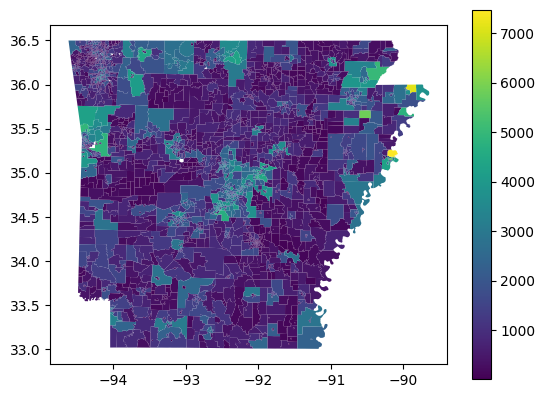

In [40]:
ar_precincts.plot('Total_population', legend=True)

### Exports

#### To Seawulf

In [41]:
final = ar_precincts.rename(columns={
    "name"           : "Unique_ID",
    "votes_dem"      : "Kamala D. Harris",
    "votes_rep"      : "Donald J. Trump",
    "votes_other"    : "Other_candidates",
    "votes_total"    : "Total_votes",
    "geometry"       : "geometry"
})

final = final.drop(columns=["White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage"])
final

,Unique_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,"MULTIPOLYGON (((-91.52313 34.47881, -91.5234 3..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,"POLYGON ((-91.38939 34.1162, -91.38913 34.1162..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,"POLYGON ((-91.32906 34.28234, -91.3327 34.2822..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,"POLYGON ((-93.15995 35.2133, -93.15995 35.2133..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.771656,0.000000,69.264875,45.229594,878.266125,"POLYGON ((-93.27993 35.21256, -93.27951 35.212..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.619378,2.686534,2.302779,13.816510,160.425201,"POLYGON ((-93.70875 34.83304, -93.70873 34.833..."
2679,05149-24 - Waveland,149,18,69,1,88,253.901601,7.571889,4.456923,9.800575,275.730988,"POLYGON ((-93.59987 35.14713, -93.59987 35.147..."


In [42]:
final.to_file("../output/Arkansas/seawulf.gpkg", driver="GPKG")

#### To Application

In [49]:
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((-91.52313 34.47881, -91.5234 3..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((-91.38939 34.1162, -91.38913 34.1162..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((-91.32906 34.28234, -91.3327 34.2822..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((-93.15995 35.2133, -93.15995 35.2133..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.771656,0.000000,69.264875,45.229594,878.266125,0.869636,0.000000,0.078865,0.051499,"POLYGON ((-93.27993 35.21256, -93.27951 35.212..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.619378,2.686534,2.302779,13.816510,160.425201,0.882775,0.016746,0.014354,0.086124,"POLYGON ((-93.70875 34.83304, -93.70873 34.833..."
2679,05149-24 - Waveland,149,18,69,1,88,253.901601,7.571889,4.456923,9.800575,275.730988,0.920831,0.027461,0.016164,0.035544,"POLYGON ((-93.59987 35.14713, -93.59987 35.147..."


In [50]:
precincts = ar_precincts[['name', 'Total_population',
       "White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage",
       'geometry']]
precincts['GEOID'] = precincts['name']
precincts['total_population'] = precincts['Total_population']
precincts['black_percentage'] = precincts['Black_percentage'] * 100
precincts['latino_percentage'] = precincts['Latino_percentage'] * 100
precincts['other_percentage'] = precincts['Other_percentage'] * 100
precincts = precincts[['GEOID', 'name', 'total_population',
       'black_percentage', 'latino_percentage', 'other_percentage',
       'geometry']]
precincts

,GEOID,name,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52313 34.47881, -91.5234 3..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.1162, -91.38913 34.1162..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32906 34.28234, -91.3327 34.2822..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,352.687248,9.572969,15.071900,6.663532,"POLYGON ((-93.15995 35.2133, -93.15995 35.2133..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,878.266125,0.000000,7.886547,5.149873,"POLYGON ((-93.27993 35.21256, -93.27951 35.212..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,160.425201,1.674633,1.435422,8.612431,"POLYGON ((-93.70875 34.83304, -93.70873 34.833..."
2679,05149-24 - Waveland,05149-24 - Waveland,275.730988,2.746115,1.616403,3.554397,"POLYGON ((-93.59987 35.14713, -93.59987 35.147..."


In [51]:
cols = {
    'GEOID' : 'GEOID',
    'name' : 'precinct', 
}

precincts = precincts.rename(columns=cols)
precincts

,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52313 34.47881, -91.5234 3..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.1162, -91.38913 34.1162..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32906 34.28234, -91.3327 34.2822..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,352.687248,9.572969,15.071900,6.663532,"POLYGON ((-93.15995 35.2133, -93.15995 35.2133..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,878.266125,0.000000,7.886547,5.149873,"POLYGON ((-93.27993 35.21256, -93.27951 35.212..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,160.425201,1.674633,1.435422,8.612431,"POLYGON ((-93.70875 34.83304, -93.70873 34.833..."
2679,05149-24 - Waveland,05149-24 - Waveland,275.730988,2.746115,1.616403,3.554397,"POLYGON ((-93.59987 35.14713, -93.59987 35.147..."


<Axes: >

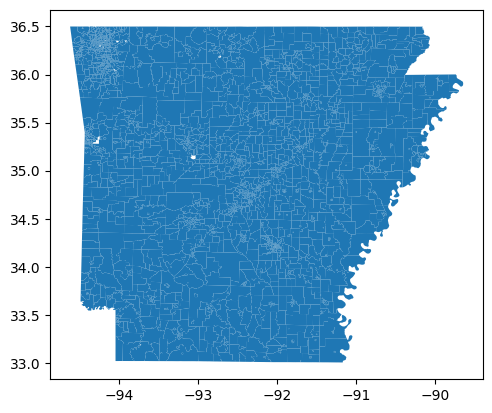

In [52]:
precincts.plot(None)

In [53]:
precincts = precincts.to_crs(epsg=4326)
topo = tp.Topology(precincts)

topo.to_json("../output/Arkansas/Arkansas_precincts_topo.topojson")

<Axes: >

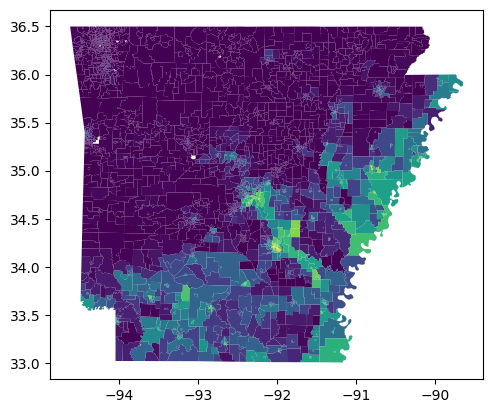

In [48]:
gdf = topo.to_gdf() 
gdf.plot("black_percentage")